This example assumes some familiarity with how the basic DiaBayes operations work (forward modelling, inversion, ...).
See `examples/simple_inversion.ipynb` for an introduction using the rate-and-state friction formulation.

The notebook below will cover similar modelling concepts using the _Chen-Niemeijer-Spiers_ (CNS) model.

In [1]:
%matplotlib widget

In [2]:
import jax.numpy as jnp
import matplotlib.pyplot as plt

import diabayes as db
from diabayes.forward_models import Forward, cns, cns_porosity, springblock, sundman_cns, steady_state_porosity, slip_rate
from diabayes.solver import ODESolver

## 1. Forward modelling

First we define the CNS and spring-block parameters, and assume that we start at steady-state:

In [3]:
# Constants
h = 1e-3      # Gouge layer thickness [m]
phi0 = 0.03   # Minimum porosity (not initial porosity!) [-]
v0 = 1e-6     # Reference velocity [m/s]
constants = db.CNSConstants(h=h, phi0=phi0, v0=v0)

# Spring-block constants
k = 1e2       # Stiffness [1/m]
v_lp = 1e-5   # Load-point velocity [m/s]
block_constants = db.SpringBlockConstants(k=k, v_lp=v_lp)

# Parameters (all dimensionless)
alpha = 0.01   # Rate parameter
beta = 0.3     # Dilatancy geometric factor
phi_c = 0.4    # Critical-state porosity
xi = 1e-1      # Creep process rate parameter
mu0 = 0.6      # Reference friction
params = db.CNSParams(alpha=alpha, beta=beta, phi_c=phi_c, xi=xi, mu0=mu0)

# Calculate the steady-state porosity from these parameters
phi_ini = steady_state_porosity(v0, mu0, params, constants)
print(f"Steady-state porosity: {phi_ini:.3f}")

Steady-state porosity: 0.218


Note that this steady-state porosity does not directly correspond with a steady-state friction coefficient.
Rather, it corresponds to the solution of $\dot{\phi} = g(\mu, v, \phi) = 0$, where $\mu$ and $v$ are fixed by the user.

The next step is to assemble the forward model and solver.
We make use of a Sundman transformation to regularise the ODE and stabilise the solution.
For fun, we can also define slip as a second "state parameter" and integrate its derivative (slip rate) over time.
This will give us access to both time and fault slip coming out of the forward simulation.

In [4]:
state_dict = {"phi": cns_porosity, "slip": slip_rate}
forward = Forward(friction_model=cns, state_evolution=state_dict, stress_transfer=springblock, sundman=sundman_cns)
solver = ODESolver(forward_model=forward)

# Set initial values
forward.set_initial_values(mu=mu0, phi=phi_ini, slip=0.0)
y0 = forward.variables
print(y0)

Variables(mu=0.6, phi=0.21750588113041144, slip=0.0, t=0.0)


In [5]:
# The time samples for which we want a solution
t = jnp.linspace(0, 1000., 1000)

# Run the forward simulation
result = solver.solve_forward(
    t, y0, params=params,
    friction_constants=constants,
    block_constants=block_constants
)

Note that, while the input parameters were normalised (non-dimensionalised), the result of the ODE integration is given in physical time units (seconds) by scaling with a factor `constants.h / constants.v0`.
Similarly, the [Sundman transformation](https://martijnende.github.io/diabayes/user-guide/forward/chen-niemeijer-spiers.html#numerical-solution-strategy) was inverted to result in a physical time base rather than the tranformed one.

Since we included slip as an additional "state parameter", we can extract it directly from the `result` object.
Alternatively, you first compute the slip rate with `v = cns(...)` and then integrate `v` over time to get slip (possibly less accurate).

Text(0.5, 0, 'slip [m]')

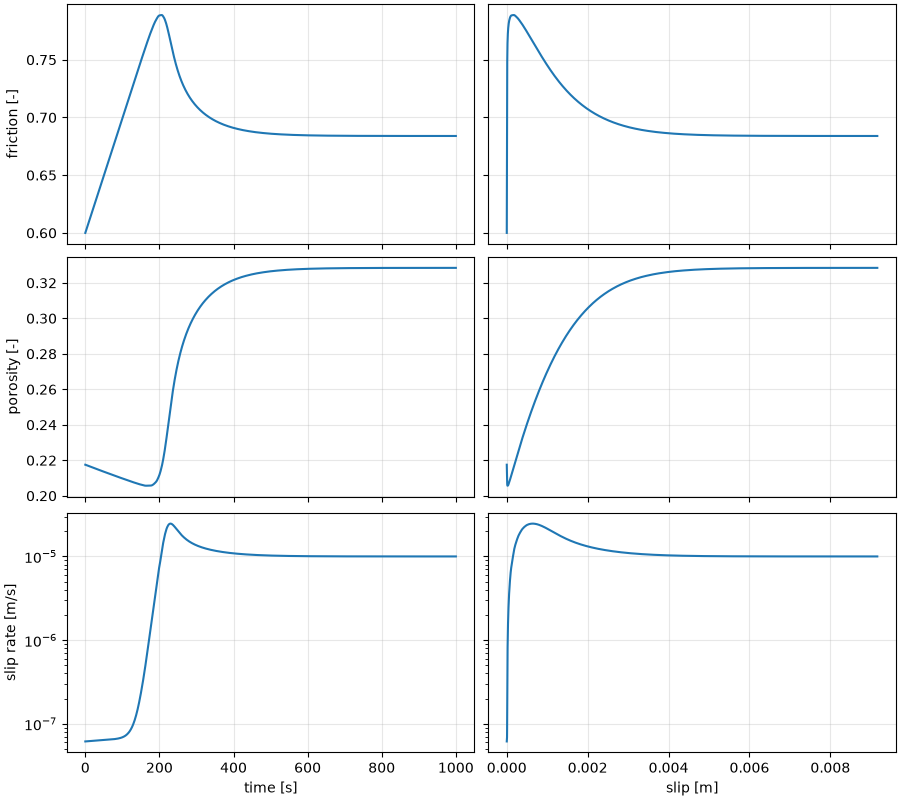

In [6]:
mu = result.mu
phi = result.phi
slip = result.slip
# Compute a time series of slip rates
v = cns(result, params, constants)

plt.close("all")
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(9, 8), constrained_layout=True, sharex="col", sharey="row")

for axrow, d in zip(axes, (mu, phi, v)):
    for ax, l in zip(axrow, (t, slip)):
        ax.plot(l, d)
        ax.grid(zorder=-1, alpha=0.3)
axes[0, 0].set_ylabel("friction [-]")
axes[1, 0].set_ylabel("porosity [-]")
axes[2, 0].set_ylabel("slip rate [m/s]")

for ax in axes[2]:
    ax.set_yscale("log")
axes[2, 0].set_xlabel("time [s]")
axes[2, 1].set_xlabel("slip [m]")

Due to the transition from velocity-weakening to -strengthening that is inherent to the CNS formulation, stick-slip limit cycles are inherently stable.
This means that we can simulate stick-slip behaviour without resorting to some form of inertial damping (inertia of the block, or radiation damping).
If you try this with RSF, the stick slips will eventually blow up to infinite slip rates, or die out to fall back into steady-state.

In [7]:
# Reduce the spring stiffness by a factor 10
k_unstable = 1e1
block_constants_unstable = db.SpringBlockConstants(k=k_unstable, v_lp=v_lp)

# Instead of using fixed time samples, we will request the time samples
# from the adaptive ODE solver, which give higher time resolution when
# the slip rate is higher. We still need to provide a time vector from
# which the start and stop time values are taken.
t_range = jnp.linspace(0, 10_000., 2)

# Run the forward simulation
result_unstable = solver.solve_forward(
    t_range, y0, params=params,
    friction_constants=constants,
    block_constants=block_constants_unstable,
    interpolate_time=False  # Request time samples from the solver
)

To see the effect of the adaptive solver time stepping, we can plot the results as dotted lines, where each dot indicates one time step.
Note how the time resolution increases in accordance with the acceleration.
When providing a fixed time vector (alongside `interpolate_time=True`), the ODE solution is interpolated onto this regular time grid, which results in an undersampling of the high-acceleration parts of the stick-slip cycle.
Since the interpolation is done only after the ODE integration is completed, the solution itself will always be accurate regardless of the value of `interpolate_time`.

Text(0.5, 0, 'slip [m]')

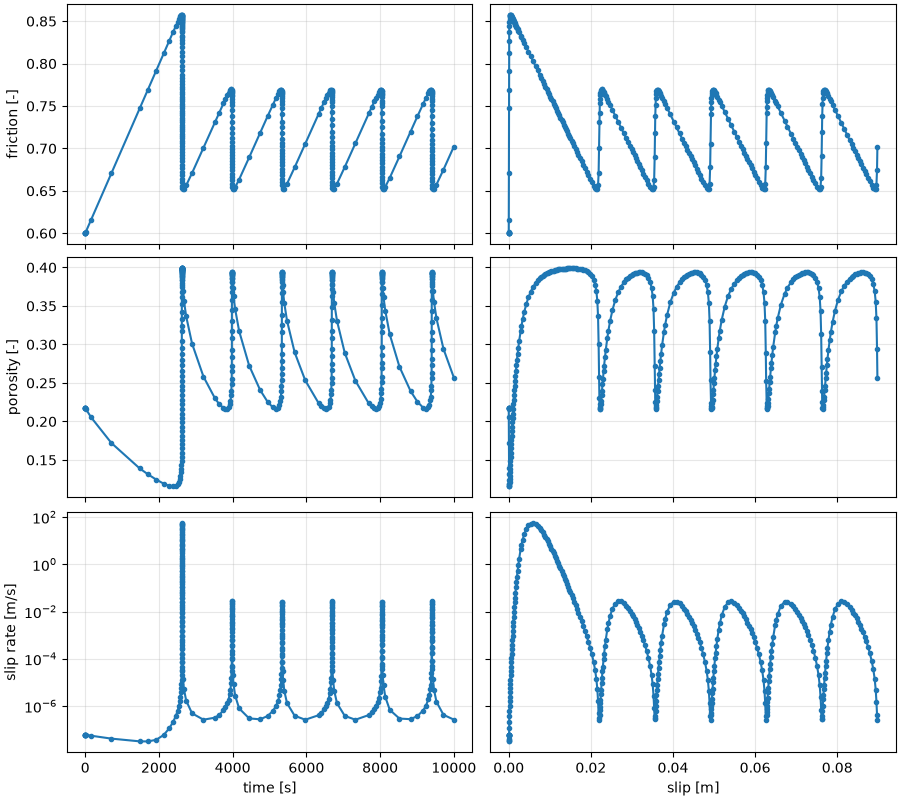

In [11]:
mu = result_unstable.mu
phi = result_unstable.phi
slip = result_unstable.slip
t2 = result_unstable.t  # Take the time samples from the solver
v = cns(result_unstable, params, constants)

plt.close("all")
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(9, 8), constrained_layout=True, sharex="col", sharey="row")

for axrow, d in zip(axes, (mu, phi, v)):
    for ax, l in zip(axrow, (t2, slip)):
        ax.plot(l, d, ".-")
        ax.grid(zorder=-1, alpha=0.3)
axes[0, 0].set_ylabel("friction [-]")
axes[1, 0].set_ylabel("porosity [-]")
axes[2, 0].set_ylabel("slip rate [m/s]")

for ax in axes[2]:
    ax.set_yscale("log")
axes[2, 0].set_xlabel("time [s]")
axes[2, 1].set_xlabel("slip [m]")

An alternative way to visualise the stick-slip cycles, is to plot them in a _phase space_, with $\dot{\mu} \propto v$ so that the phase space is spanned by $(\mu, \dot{\mu}) = (\mu, v)$.
From this representation, it is clear that the system rapidly settles into a stable limit cycle.
For RSF, you would either see a spiral going in converging on a point, or outward diverging into infinity, depending on the initial state.

Text(0, 0.5, 'slip rate [m/s]')

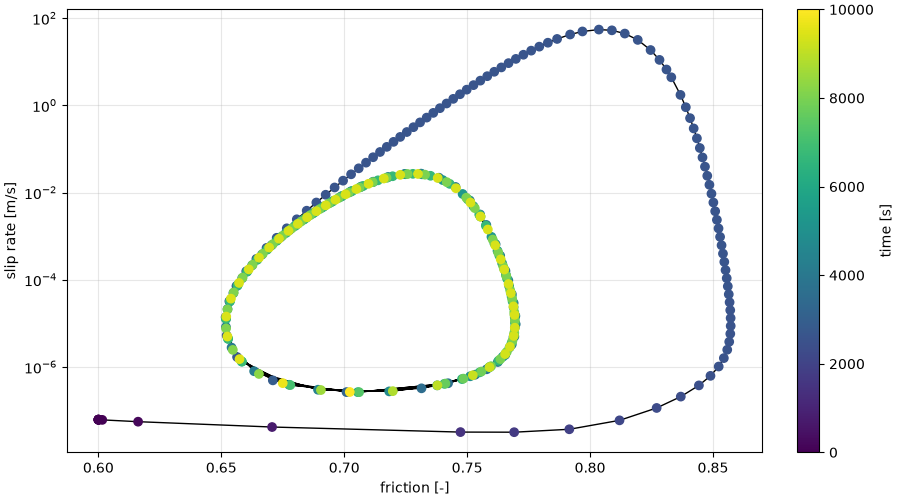

In [12]:
plt.close("all")
fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
ax.plot(mu, v, c="k", lw=1)
cs = ax.scatter(mu, v, c=t2, zorder=999)
cb = fig.colorbar(cs, ax=ax, label="time [s]")
ax.grid(zorder=-1, alpha=0.3)
ax.set_yscale("log")
ax.set_xlabel("friction [-]")
ax.set_ylabel("slip rate [m/s]")

## 2. Maximum-likelihood inversion

In the cell below, we generate simulate noisy measurements by adding some Gaussian noise to the friction curve obtained above. We also define an initial guess of the RSF parameters that is a bit different from the true parameter values, which in practice is likely to be the case.

In [13]:
import jax.random as jr

# The JAX random number generator
key = jr.PRNGKey(42)
key, split_key = jr.split(key)
noise = jr.normal(split_key, shape=(len(t),))

# You can play around with the noise amplitude to make
# the inversion more or less challenging...
noise_amplitude = 1e-3

mu_measured = result.mu + noise * noise_amplitude

# Initial guess of the parameters
params_guess = db.CNSParams(
    alpha = 1.1 * alpha,
    beta = 1.03 * beta,
    phi_c = 1.2 * phi_c,
    xi = 2 * xi,
    mu0 = mu0,
)

# Do the maximum-likelihood inversion
# Set verbose=True to get intermediate messages
# of the solver progress
inv_result = solver.max_likelihood_inversion(
    t, mu_measured, y0,
    params=params_guess,
    friction_constants=constants,
    block_constants=block_constants,
    verbose=True
)

Step: 0, Accepted steps: 0, Steps since acceptance: 0, Loss on this step: 1.593594389593607, Loss on the last accepted step: 0.0, Step size: 1.0, y: alpha=0.011000000000000001, beta=0.309, phi_c=0.48, xi=0.2, mu0=0.6, y on the last accepted step: alpha=0.011000000000000001, beta=0.309, phi_c=0.48, xi=0.2, mu0=0.6
Step: 1, Accepted steps: 1, Steps since acceptance: 0, Loss on this step: 0.08050782132017097, Loss on the last accepted step: 1.593594389593607, Step size: 3.5, y: alpha=0.042931248501878225, beta=0.3589509288511151, phi_c=0.4341250571814458, xi=0.2714387166197954, mu0=0.48037517605803204, y on the last accepted step: alpha=0.042931248501878225, beta=0.3589509288511151, phi_c=0.4341250571814458, xi=0.2714387166197954, mu0=0.48037517605803204
Step: 2, Accepted steps: 2, Steps since acceptance: 0, Loss on this step: 0.05007101707954835, Loss on the last accepted step: 0.08050782132017097, Step size: 3.5, y: alpha=0.018569203726492286, beta=0.2126468719901107, phi_c=0.4504439654

The result of the inversion (`inv_result`) is an [`optimistix.Solution`](https://docs.kidger.site/optimistix/api/solution/#optimistix.Solution) object, similar to the `diffrax.Solution` object we've seen before. The inverted parameters are accessed through `inv_result.value`, which contains a `RSFParams` object.

We can get these parameters and run another forward simulation to see if we obtained an acceptable fit with the data:

Inverted parameters: alpha=0.009875643172496203, beta=0.30104499193721934, phi_c=0.3986266997550305, xi=0.09722302003970167, mu0=0.6010223314796508
True parameters: alpha=0.01, beta=0.3, phi_c=0.4, xi=0.1, mu0=0.6


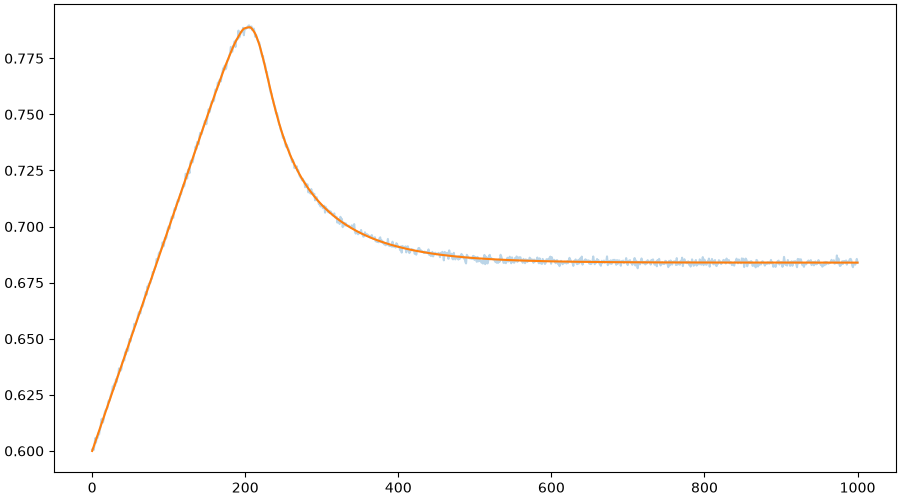

In [15]:
params_inv = inv_result.value

result_predicted = solver.solve_forward(t, y0, params_inv, constants, block_constants)

print(f"Inverted parameters: {params_inv}")
print(f"True parameters: {params}")

plt.close("all")
fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
ax.plot(t, mu_measured, alpha=0.3)
ax.plot(t, result_predicted.mu)